ГЕНЕРАЦИЯ ДАТАСЕТА (ДЛЯ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ)

,date,sales
0,2024-01-01,69.34
1,2024-01-02,84.09
2,2024-01-03,95.64
3,2024-01-04,81.68
4,2024-01-05,82.71
...,...,...
745,2026-01-15,324.00
746,2026-01-16,319.55
747,2026-01-17,334.23
748,2026-01-18,339.07


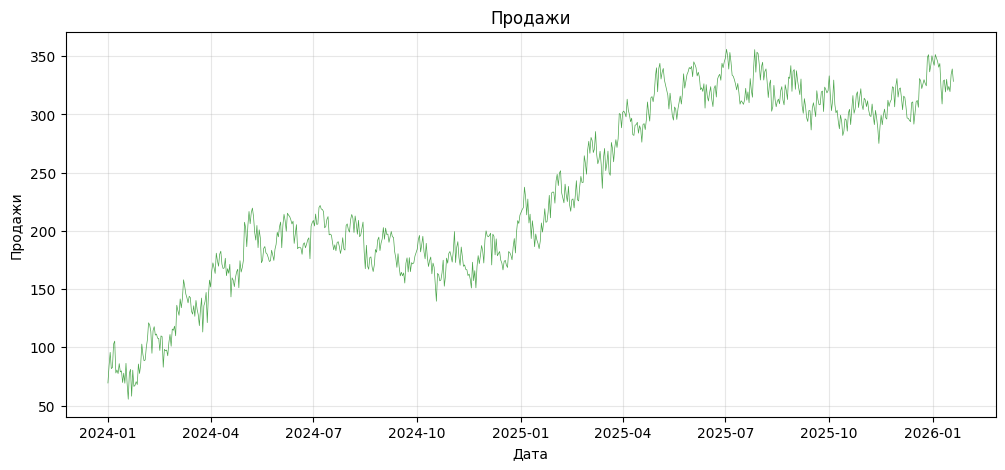

In [529]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv', parse_dates=['date'])
display(df)

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], linewidth=0.5, alpha=0.7, color='green')
plt.title("Продажи")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.grid(True, alpha=0.3)
plt.show()

ПРЕДОБРАБОТКА ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ 

In [530]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def add_lags(df, lag_days=[1, 7, 14, 30]):
    df = df.copy()
    for lag in lag_days:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df = df.dropna()
    return df

def preprocess_for_lr(df, scaler=None, is_train=True):
    df = df.copy()
    
    # Обработка дат
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    # Признаки для модели (лаги + сезонность)
    features = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 
                'day_of_week', 'month', 'weekend']
    
    # Целевая переменная
    target = 'sales'
    
    # Масштабирование
    X = df[features].values
    
    if is_train:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    y = df[target].values

    return X_scaled, y, scaler, df

# Загрузка данных
df = pd.read_csv('sales_data.csv', parse_dates=['date'])

# Добавляем лаги (до разделения)
df = add_lags(df, lag_days=[1, 7, 14, 30])

# Разделение на train/test (80/20)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

# Предобработка
X_train, y_train, scaler, train_prep = preprocess_for_lr(train, is_train=True)
X_test, y_test, _, test_prep = preprocess_for_lr(test, scaler=scaler, is_train=False)

ЛИНЕЙНАЯ РЕГРЕССИЯ

Линейная регрессия:
    R² на обучающей: 0.9829
    R² на тестовой:  0.6801
    MAE:             7.41


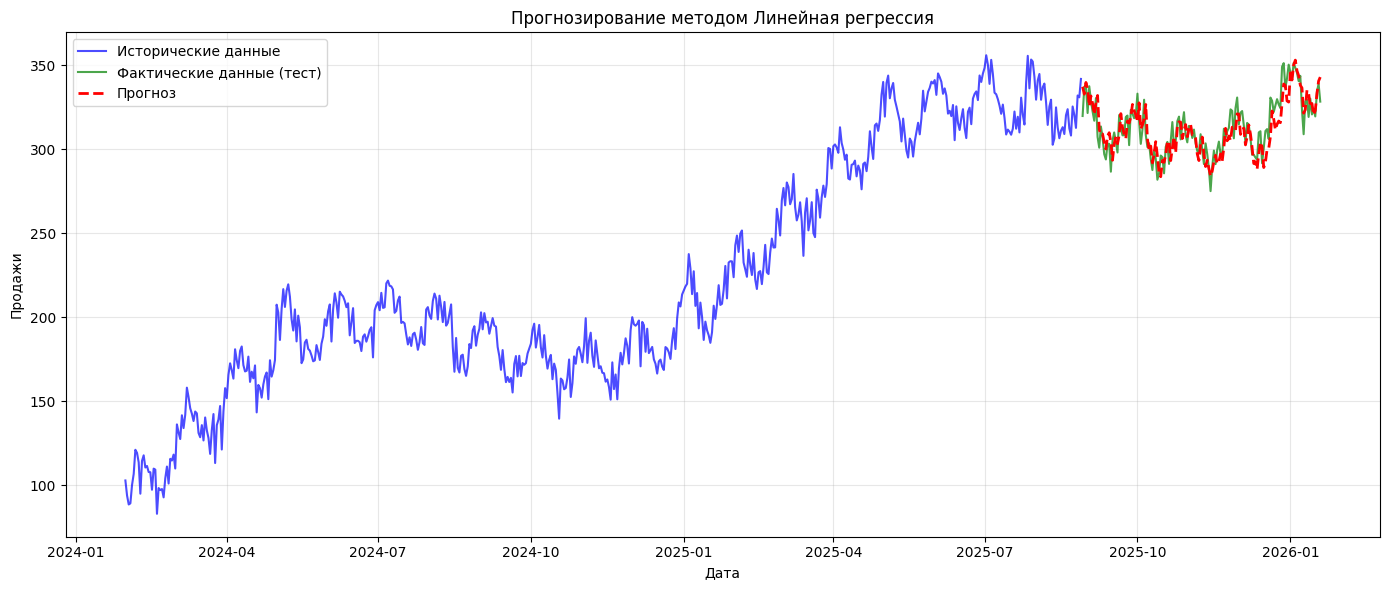

In [531]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def linear_regression(X_train, y_train, X_test, y_test, train_prep, test_prep):
    # Обучение
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Прогнозы
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    # Вывод
    print("Линейная регрессия:")
    print(f"    R² на обучающей: {r2_train:.4f}")
    print(f"    R² на тестовой:  {r2_test:.4f}")
    print(f"    MAE:             {mae:.2f}")
    
    # График
    plt.figure(figsize=(14, 6))
    
    train_dates = train_prep['date'].values
    test_dates = test_prep['date'].values
    
    plt.plot(train_dates, y_train, label="Исторические данные", color="blue", alpha=0.7)
    plt.plot(test_dates, y_test, label="Фактические данные (тест)", color="green", alpha=0.7)
    plt.plot(test_dates, y_test_pred, label="Прогноз", color="red", linestyle="--", linewidth=2)
    
    plt.title("Прогнозирование методом Линейная регрессия")
    plt.xlabel("Дата")
    plt.ylabel("Продажи")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model, y_test_pred, {"r2_train": r2_train, "r2_test": r2_test, "mae": mae}

# Запуск
model, predictions, metrics = linear_regression(X_train, y_train, X_test, y_test, train_prep, test_prep)

ПРЕДСКАЗАНИЕ НА БУДУЩЕЕ (БЕЗ ИЗВЕСТНЫХ ЗАРАНЕЕ ДАННЫХ ДЛЯ ПРОВЕРКИ)

Модель обучена на 720 днях



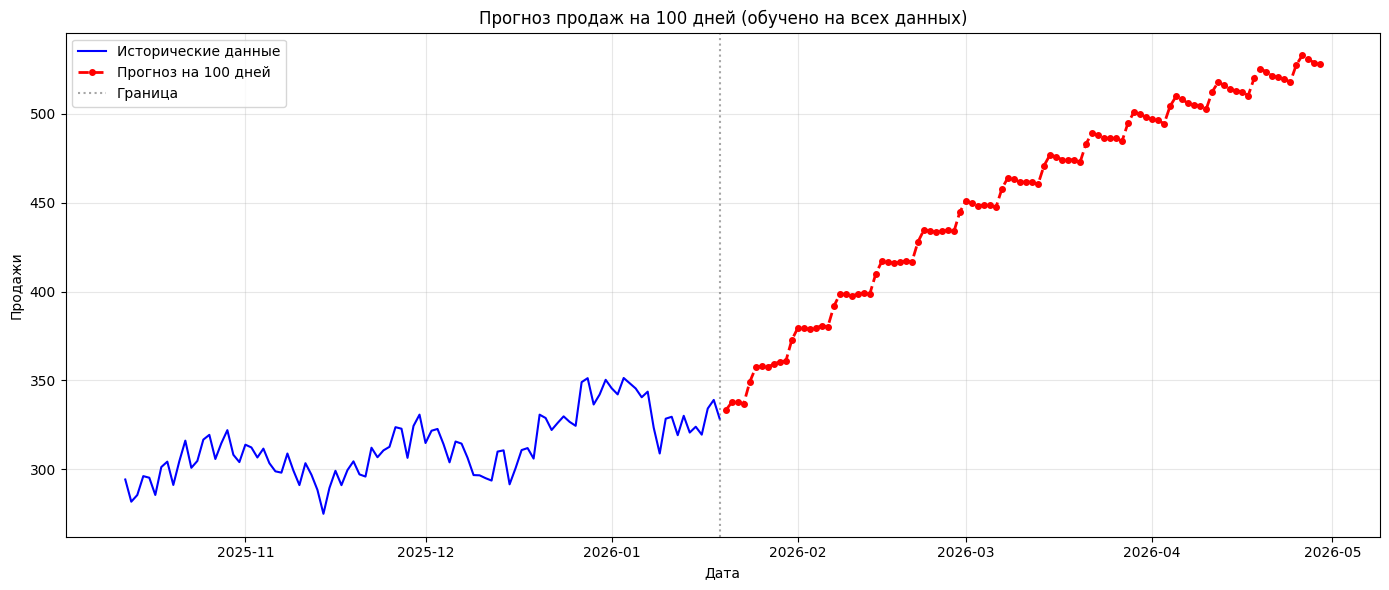


Прогноз на 100 дней:
         date  forecast
0  2026-01-20    333.25
1  2026-01-21    337.75
2  2026-01-22    337.98
3  2026-01-23    337.05
4  2026-01-24    349.19
..        ...       ...
95 2026-04-25    527.34
96 2026-04-26    532.68
97 2026-04-27    530.81
98 2026-04-28    528.46
99 2026-04-29    527.63

[100 rows x 2 columns]


In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# def add_lags(df, lag_days=[1, 7, 14, 30]):
#     df = df.copy()
#     for lag in lag_days:
#         df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
#     df = df.dropna()
#     return df

# def preprocess_for_lr(df, scaler=None):
#     df = df.copy()
    
#     df['day_of_week'] = df['date'].dt.dayofweek
#     df['month'] = df['date'].dt.month
#     df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
#     features = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 
#                 'day_of_week', 'month', 'weekend']
    
#     X = df[features].values
    
#     if scaler is None:
#         scaler = StandardScaler()
#         X_scaled = scaler.fit_transform(X)
#     else:
#         X_scaled = scaler.transform(X)
    
#     return X_scaled, df['sales'].values, scaler

# # ========== ПАРАМЕТРЫ ==========
# FORECAST_DAYS = 100
# HISTORY_DAYS = FORECAST_DAYS

# # Загрузка и подготовка
# df = pd.read_csv('sales_data.csv', parse_dates=['date'])
# df_with_lags = add_lags(df, lag_days=[1, 7, 14, 30])

# # ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ (без разделения)
# X_all, y_all, scaler = preprocess_for_lr(df_with_lags)

# # Обучение модели
# model = LinearRegression()
# model.fit(X_all, y_all)

# print(f"Модель обучена на {len(X_all)} днях")
# print()

# # Прогноз на будущее
# last_date = df['date'].iloc[-1]
# future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='D')

# # Берем последние доступные лаги из данных
# last_lags = {
#     1: df['sales'].iloc[-1],
#     7: df['sales'].iloc[-7],
#     14: df['sales'].iloc[-14],
#     30: df['sales'].iloc[-30]
# }

# # Прогнозируем последовательно
# future_predictions = []
# current_lags = last_lags.copy()

# for future_date in future_dates:
#     row = {
#         'sales_lag_1': current_lags[1],
#         'sales_lag_7': current_lags[7],
#         'sales_lag_14': current_lags[14],
#         'sales_lag_30': current_lags[30],
#         'day_of_week': future_date.dayofweek,
#         'month': future_date.month,
#         'weekend': 1 if future_date.dayofweek >= 5 else 0
#     }
    
#     features_array = np.array([[row['sales_lag_1'], row['sales_lag_7'], row['sales_lag_14'], 
#                                  row['sales_lag_30'], row['day_of_week'], row['month'], row['weekend']]])
#     features_scaled = scaler.transform(features_array)
    
#     pred = model.predict(features_scaled)[0]
#     future_predictions.append(pred)
    
#     current_lags = {
#         1: pred,
#         7: current_lags[1],
#         14: current_lags[7],
#         30: current_lags[14]
#     }

# # График
# plt.figure(figsize=(14, 6))

# history_df = df.iloc[-HISTORY_DAYS:]

# plt.plot(history_df['date'], history_df['sales'], label="Исторические данные", color="blue", linewidth=1.5)
# plt.plot(future_dates, future_predictions, label=f"Прогноз на {FORECAST_DAYS} дней", 
#          color="red", linestyle="--", linewidth=2, marker="o", markersize=4)

# plt.axvline(x=df['date'].iloc[-1], color='gray', linestyle=':', alpha=0.7, label='Граница')

# plt.title(f"Прогноз продаж на {FORECAST_DAYS} дней (обучено на всех данных)")
# plt.xlabel("Дата")
# plt.ylabel("Продажи")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Сохраняем прогноз
# forecast_df = pd.DataFrame({
#     'date': future_dates,
#     'forecast': [round(x, 2) for x in future_predictions]
# })
# print(f"\nПрогноз на {FORECAST_DAYS} дней:")
# print(forecast_df)

# forecast_df.to_csv('future_forecast.csv', index=False)

Метрики на обучающей выборке: 
    R² :   0.8990
    MAE:  20.48

КОЭФФИЦИЕНТЫ МОДЕЛИ:
    sales_lag_14: 71.6399
    day_of_week: -0.2639
    month: -2.0755
    weekend: 0.4099
    intercept: 236.31



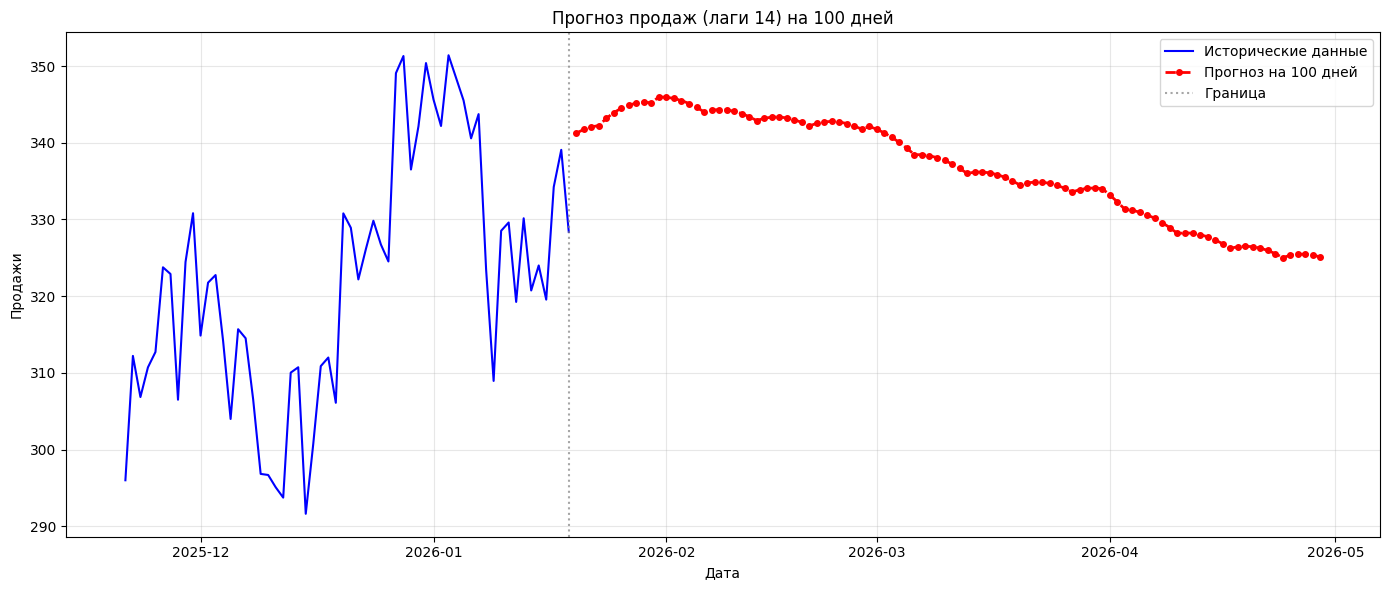


Прогноз на 100 дней:
        date  forecast
0 2026-01-20    341.24
1 2026-01-21    341.73
2 2026-01-22    342.06
3 2026-01-23    342.24
4 2026-01-24    343.18
5 2026-01-25    343.92
6 2026-01-26    344.50
7 2026-01-27    344.91
8 2026-01-28    345.16
9 2026-01-29    345.26
...
         date  forecast
90 2026-04-20    326.45
91 2026-04-21    326.27
92 2026-04-22    325.96
93 2026-04-23    325.55
94 2026-04-24    325.03
95 2026-04-25    325.32
96 2026-04-26    325.46
97 2026-04-27    325.47
98 2026-04-28    325.36
99 2026-04-29    325.11


In [570]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def add_lags(df, lag_days=[14]):
    df = df.copy()
    for lag in lag_days:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df = df.dropna()
    return df

def preprocess_for_lr(df, scaler=None):
    df = df.copy()
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    features = ['sales_lag_14', 'day_of_week', 'month', 'weekend']
    
    X = df[features].values
    
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    return X_scaled, df['sales'].values, scaler

FORECAST_DAYS = 100
HISTORY_DAYS = 60

# Загрузка и подготовка
df = pd.read_csv('sales_data.csv', parse_dates=['date'])
df_with_lags = add_lags(df, lag_days=[14])

# Обучение на всех данных
X_all, y_all, scaler = preprocess_for_lr(df_with_lags)

# Обучение модели
model = LinearRegression()
model.fit(X_all, y_all)

# Метрики
y_all_pred = model.predict(X_all)

r2 = r2_score(y_all, y_all_pred)
mae = mean_absolute_error(y_all, y_all_pred)
rmse = np.sqrt(mean_squared_error(y_all, y_all_pred))
mape = np.mean(np.abs((y_all - y_all_pred) / y_all)) * 100

print("Метрики на обучающей выборке: ")
print(f"    R² :   {r2:.4f}")
print(f"    MAE:  {mae:.2f}")
print()

print("КОЭФФИЦИЕНТЫ МОДЕЛИ:")
features = ['sales_lag_14', 'day_of_week', 'month', 'weekend']
for name, coef in zip(features, model.coef_):
    print(f"    {name}: {coef:.4f}")
print(f"    intercept: {model.intercept_:.2f}")
print()

# Прогноз на будущее
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='D')

# Берем последние доступные лаги из данных
current_lags = {
    14: df['sales'].iloc[-14]
}

# Прогнозируем последовательно
future_predictions = []

for future_date in future_dates:
    row = {
        'sales_lag_14': current_lags[14],
        'day_of_week': future_date.dayofweek,
        'month': future_date.month,
        'weekend': 1 if future_date.dayofweek >= 5 else 0
    }
    
    features_array = np.array([[
        row['sales_lag_14'], 
        row['day_of_week'], 
        row['month'], 
        row['weekend']
    ]])
    features_scaled = scaler.transform(features_array)
    
    pred = model.predict(features_scaled)[0]
    future_predictions.append(pred)
    
    # Обновляем лаги для следующего шага
    current_lags = {
        14: pred
    }

plt.figure(figsize=(14, 6))

history_df = df.iloc[-HISTORY_DAYS:]

plt.plot(history_df['date'], history_df['sales'], label="Исторические данные", 
         color="blue", linewidth=1.5)
plt.plot(future_dates, future_predictions, label=f"Прогноз на {FORECAST_DAYS} дней", 
         color="red", linestyle="--", linewidth=2, marker="o", markersize=4)

plt.axvline(x=df['date'].iloc[-1], color='gray', linestyle=':', alpha=0.7, label='Граница')

plt.title(f"Прогноз продаж (лаги 14) на {FORECAST_DAYS} дней")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast': [round(x, 2) for x in future_predictions]
})

print(f"\nПрогноз на {FORECAST_DAYS} дней:")
print(forecast_df.head(10))
print("...")
print(forecast_df.tail(10))

forecast_df.to_csv('future_forecast.csv', index=False)